<a href="https://colab.research.google.com/github/weagan/JEPA/blob/main/VIT_Simple_ijepa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple I-JEPA (Colab/Kaggle Ready)
This notebook is a minimal implementation of JEPA-style representation learning.

In [ ]:
!pip install torch torchvision tqdm -q

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import random

### Vision Transformer Components

Before defining the full ViT-based `Encoder`, we need to implement its core components: `PatchEmbedding`, `Attention`, `FeedForward`, and `TransformerBlock`.

In [ ]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, dim):
        super().__init__()
        image_height, image_width = image_size, image_size
        patch_height, patch_width = patch_size, patch_size

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        patch_dim = in_channels * patch_height * patch_width

        self.patch_size = patch_size
        self.num_patches = num_patches

        self.proj = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, img):
        x = self.proj(img).flatten(2).transpose(1, 2) # B, C, H, W -> B, D, N -> B, N, D
        return x

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, dim, hidden_dim, dropout = 0.):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
class Attention(nn.Module):
    def __init__(self, dim, heads = 8, dim_head = 64, dropout = 0.):
        super().__init__()
        inner_dim = dim_head *  heads
        project_out = not (heads == 1 and dim_head == dim)

        self.heads = heads
        self.scale = dim_head ** -0.5

        self.attend = nn.Softmax(dim = -1)
        self.dropout = nn.Dropout(dropout)

        self.to_qkv = nn.Linear(dim, inner_dim * 3, bias = False)

        self.to_out = nn.Sequential(
            nn.Linear(inner_dim, dim),
            nn.Dropout(dropout)
        ) if project_out else nn.Identity()

    def forward(self, x):
        qkv = self.to_qkv(x).chunk(3, dim = -1)
        q, k, v = map(lambda t: t.reshape(t.shape[0], t.shape[1], self.heads, -1).transpose(1, 2), qkv)

        dots = torch.matmul(q, k.transpose(-1, -2)) * self.scale

        attn = self.attend(dots)
        attn = self.dropout(attn)

        out = torch.matmul(attn, v)
        # Fix: Ensure reshape uses the shape of the transposed tensor
        out = out.transpose(1, 2) # (B, seq_len, heads, dim_head)
        out = out.reshape(out.shape[0], out.shape[1], -1) # (B, seq_len, heads * dim_head)
        return self.to_out(out)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, dim_head, mlp_dim, dropout = 0.):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = Attention(dim, heads = heads, dim_head = dim_head, dropout = dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = FeedForward(dim, mlp_dim, dropout = dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x

A key part of the JEPA architecture is using masked inputs. Let's define the core idea:

Given an input image $x$, we create two views: a **context view** $x_c$ and a **target view** $x_t$.

- The **context view** is created by masking out parts of the original image.
- The **target view** is typically the original image or another augmented view.

Then, we learn representations by having a **predictor** $P$ learn to predict the representation of the target view $E_T(x_t)$ from the representation of the context view $E_C(x_c)$:

$$\mathcal{L} = \| P(E_C(x_c)) - E_T(x_t) \|_2^2$$

Where:
- $E_C$ is the **context encoder**
- $E_T$ is the **target encoder** (an EMA-smoothed version of $E_C$)
- $P$ is the **predictor MLP**

The `self.net` within the `Encoder` class transforms an input tensor $x \in \mathbb{R}^{B \times 3 \times H \times W}$ (where $B$ is batch size, $3$ is input channels, $H$ and $W$ are height and width) into a feature vector $z \in \mathbb{R}^{B \times \text{dim}}$. This transformation can be described as a sequence of operations:

1.  **First Convolutional Layer + ReLU**: Applies a 2D convolution with 3 input channels, 32 output channels, kernel size 4, stride 2, and padding 1, followed by a Rectified Linear Unit (ReLU) activation.
    $$O_1 = \text{ReLU}(\text{Conv2d}(x, \text{in}=3, \text{out}=32, \text{kernel}=4, \text{stride}=2, \text{padding}=1))$$

2.  **Second Convolutional Layer + ReLU**: Applies another 2D convolution with 32 input channels, 64 output channels, kernel size 4, stride 2, and padding 1, followed by a ReLU activation.
    $$O_2 = \text{ReLU}(\text{Conv2d}(O_1, \text{in}=32, \text{out}=64, \text{kernel}=4, \text{stride}=2, \text{padding}=1))$$

3.  **Third Convolutional Layer**: Applies a final 2D convolution with 64 input channels, `dim` (e.g., 128) output channels, kernel size 4, stride 2, and padding 1.
    $$O_3 = \text{Conv2d}(O_2, \text{in}=64, \text{out}=\text{dim}, \text{kernel}=4, \text{stride}=2, \text{padding}=1))$$

4.  **Adaptive Average Pooling**: Downsamples the spatial dimensions of $O_3$ to $1 \times 1$.
    $$O_4 = \text{AdaptiveAvgPool2d}(O_3, \text{output_size}=(1,1))$$

5.  **Flatten**: Flattens the tensor $O_4$ (which has shape $B \times \text{dim} \times 1 \times 1$) into a 2D tensor of shape $B \times \text{dim}$.
    $$z = \text{flatten}(O_4, \text{start_dim}=1)$$

Combining these, the entire `self.net` operation can be represented as:

$$z = \text{flatten}(\text{AdaptiveAvgPool2d}(\text{Conv2d}(\text{ReLU}(\text{Conv2d}(\text{ReLU}(\text{Conv2d}(x)))))))$$ Where the parameters for each `Conv2d` are as specified above.

In [ ]:
class Encoder(nn.Module):
    def __init__(self, *, image_size=64, patch_size=8, in_channels=3, dim=128,
                 depth=6, heads=8, mlp_dim=256, pool = 'cls', dim_head = 64, dropout = 0., emb_dropout = 0.):
        super().__init__()
        image_height, image_width = image_size, image_size
        patch_height, patch_width = patch_size, patch_size

        assert image_height % patch_height == 0 and image_width % patch_width == 0, 'Image dimensions must be divisible by the patch size.'

        num_patches = (image_height // patch_height) * (image_width // patch_width)
        # patch_dim = in_channels * patch_height * patch_width # Not directly used after PatchEmbedding
        assert pool in {'cls', 'mean'}, 'pool type must be either cls (class token) or mean (mean pooling)'

        self.patch_embedding = PatchEmbedding(image_size, patch_size, in_channels, dim)
        self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, dim))
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim))
        self.dropout = nn.Dropout(emb_dropout)

        self.transformer_blocks = nn.ModuleList([])
        for _ in range(depth):
            self.transformer_blocks.append(TransformerBlock(dim, heads, dim_head, mlp_dim, dropout))

        self.pool = pool
        self.to_latent = nn.Identity()

        # Output layer to match the expected feature dimension 'dim'
        # In JEPA, the encoder's role is to produce a feature vector, not directly classify.
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Linear(dim, dim) # Project to the feature dimension 'dim'
        )

    def forward(self, img):
        x = self.patch_embedding(img) # B, N, D (Batch, Num_Patches, Dimension)

        b, n, _ = x.shape

        cls_tokens = self.cls_token.expand(b, -1, -1) # Expand CLS token for the batch
        x = torch.cat((cls_tokens, x), dim=1) # Concatenate CLS token with patch embeddings
        x += self.pos_embedding[:, :(n + 1)] # Add positional embeddings
        x = self.dropout(x)

        for block in self.transformer_blocks:
            x = block(x)

        # Pool the output: either use the CLS token or mean pool over patches
        x = x.mean(dim = 1) if self.pool == 'mean' else x[:, 0]

        return self.mlp_head(self.to_latent(x))

The `self.net` within the `Predictor` class takes an input tensor $z \in \mathbb{R}^{B \times \text{dim}}$ (where $B$ is batch size, and `dim` is the feature dimension from the encoder) and transforms it into a predicted representation $P(z) \in \mathbb{R}^{B \times \text{dim}}$. This transformation involves a sequence of operations:

1.  **First Linear Layer + ReLU**: Applies a linear transformation from `dim` to `dim`, followed by a Rectified Linear Unit (ReLU) activation.
    $$L_1 = \text{ReLU}(\text{Linear}(z, \text{in}=\text{dim}, \text{out}=\text{dim}))$$

2.  **Second Linear Layer**: Applies another linear transformation from `dim` to `dim`.
    $$P(z) = \text{Linear}(L_1, \text{in}=\text{dim}, \text{out}=\text{dim})$$

Combining these, the entire `self.net` operation can be represented as:

$$P(z) = \text{Linear}(\text{ReLU}(\text{Linear}(z)))$$

In [ ]:
class Predictor(nn.Module):
    def __init__(self, dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim),
            nn.ReLU(),
            nn.Linear(dim, dim)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def ema_update(context_encoder, target_encoder, m=0.99):
    for p_s, p_t in zip(context_encoder.parameters(), target_encoder.parameters()):
        p_t.data = m * p_t.data + (1 - m) * p_s.data

In [ ]:
def make_views(x, patch_size=8, context_mask_ratio=0.5, target_extra_mask_ratio=0.1):
    B, C, H, W = x.shape
    context = x.clone()
    target = x.clone()

    num_patches_h = H // patch_size
    num_patches_w = W // patch_size

    # --- Context Masking ---
    # True means mask this patch in the context view
    context_patch_mask = (torch.rand(B, num_patches_h, num_patches_w, device=x.device) < context_mask_ratio)

    # Expand context_patch_mask to pixel-level mask
    expanded_h_mask_context = context_patch_mask.repeat_interleave(patch_size, dim=1)
    context_pixel_mask_full = expanded_h_mask_context.repeat_interleave(patch_size, dim=2).unsqueeze(1).expand(-1, C, -1, -1)

    context[context_pixel_mask_full] = 0

    # --- Target Masking ---
    # Identify patches that were *visible* in the context view (~context_patch_mask is True)
    visible_in_context_patches = ~context_patch_mask

    # From these visible_in_context_patches, randomly select some to be masked in the target view.
    # This ensures that target_patch_mask is always a subset of visible_in_context_patches,
    # fulfilling the constraint: target_patch_mask < ~context_patch_mask.
    # The target_extra_mask_ratio now controls the density of masking within the context-visible regions.
    random_selection_for_target_mask = (torch.rand(B, num_patches_h, num_patches_w, device=x.device) < target_extra_mask_ratio)
    target_patch_mask = visible_in_context_patches & random_selection_for_target_mask

    # Expand target_patch_mask to pixel-level mask
    expanded_h_mask_target = target_patch_mask.repeat_interleave(patch_size, dim=1)
    target_pixel_mask_full = expanded_h_mask_target.repeat_interleave(patch_size, dim=2).unsqueeze(1).expand(-1, C, -1, -1)

    target[target_pixel_mask_full] = 0

    return context, target

In [ ]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor()
])

train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
loader = DataLoader(train_data, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [01:38<00:00, 1.72MB/s]


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

context_encoder = Encoder().to(device)
target_encoder = Encoder().to(device)
predictor = Predictor().to(device)

target_encoder.load_state_dict(context_encoder.state_dict())
for p in target_encoder.parameters():
    p.requires_grad = False

opt = torch.optim.Adam(list(context_encoder.parameters()) + list(predictor.parameters()), lr=1e-3)

In [ ]:
for epoch in range(20):
    for x, _ in loader:
        x = x.to(device)

        context, target = make_views(x)

        z_target = target_encoder(target)
        z_context = context_encoder(context)

        pred = predictor(z_context)

        loss = F.mse_loss(pred, z_target.detach())

        opt.zero_grad()
        loss.backward()
        opt.step()

        ema_update(context_encoder, target_encoder)

    print('epoch', epoch, 'loss', loss.item())

epoch 0 loss 0.0007155798375606537
epoch 1 loss 0.011619215831160545
epoch 2 loss 0.010823002085089684
epoch 3 loss 0.011260943487286568
epoch 4 loss 0.016696974635124207
epoch 5 loss 0.047568660229444504
epoch 6 loss 0.027955377474427223
epoch 7 loss 0.029269035905599594
epoch 8 loss 0.028600696474313736
epoch 9 loss 0.047723621129989624
epoch 10 loss 0.11517558991909027
epoch 11 loss 0.02580970712006092
epoch 12 loss 0.08628116548061371
epoch 13 loss 0.029392359778285027
epoch 14 loss 0.05694463104009628
epoch 15 loss 0.014023471623659134
epoch 16 loss 0.020630434155464172
epoch 17 loss 0.04406144469976425
epoch 18 loss 0.03583507239818573
epoch 19 loss 0.0247756689786911


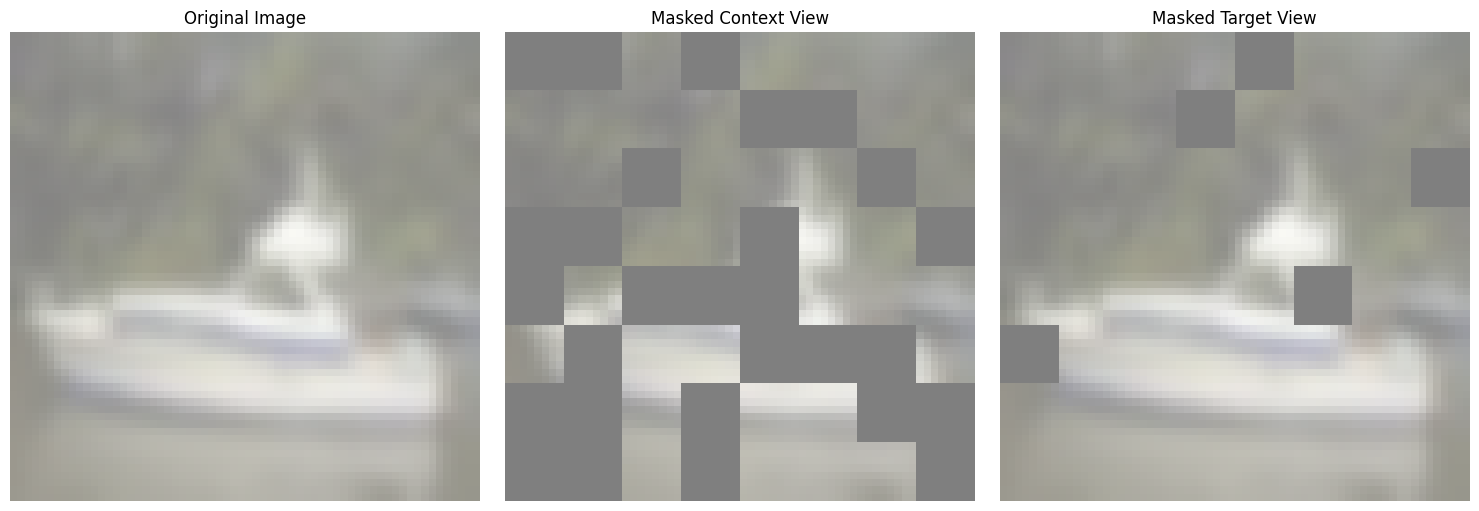

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.utils import make_grid

# Get one batch of images
x_sample, _ = next(iter(loader))
x_sample = x_sample.to(device)

# Apply make_views to get masked context and target
context_view, target_view = make_views(x_sample)

# Take the first image from the batch for visualization
original_image = x_sample[0].cpu()
masked_context_image = context_view[0].cpu()
masked_target_image = target_view[0].cpu()

# Function to unnormalize and display image
def imshow(img, title=None):
    img = img / 2 + 0.5  # Unnormalize (if normalized to [-1, 1])
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title: plt.title(title)
    plt.axis('off')

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
imshow(original_image, title='Original Image')

plt.subplot(1, 3, 2)
imshow(masked_context_image, title='Masked Context View')

plt.subplot(1, 3, 3)
imshow(masked_target_image, title='Masked Target View')

plt.tight_layout()
plt.show()

## Model Evaluation: Linear Probing

Now that the JEPA model has been trained, we can evaluate the quality of the learned representations by training a linear classifier on top of the frozen encoder. This is a common practice in self-supervised learning to assess the utility of the features for downstream tasks.

In [ ]:
# Load CIFAR-10 test dataset
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

# Define a simple linear classification head
class LinearClassifier(nn.Module):
    def __init__(self, feature_dim=128, num_classes=10):
        super().__init__()
        self.fc = nn.Linear(feature_dim, num_classes)

    def forward(self, x):
        return self.fc(x)

# Initialize the classifier and move to device
classifier = LinearClassifier().to(device)

# Freeze the context encoder for feature extraction
for param in context_encoder.parameters():
    param.requires_grad = False

# Optimizer for the linear classifier
classifier_opt = torch.optim.Adam(classifier.parameters(), lr=1e-3)

print("Setup complete for linear probing evaluation.")

Setup complete for linear probing evaluation.


### Training the Linear Classifier

We will now train the `LinearClassifier` on the features extracted from the *frozen* `context_encoder`. This means only the weights of the `LinearClassifier` will be updated during this phase.

In [ ]:
epochs_linear_probe = 20

print(f"Training linear classifier for {epochs_linear_probe} epochs...")

for epoch in range(epochs_linear_probe):
    classifier.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Extract features using the frozen context encoder
        with torch.no_grad():
            features = context_encoder(x)

        # Forward pass through classifier
        logits = classifier(features)
        loss = F.cross_entropy(logits, y)

        # Backward and optimize
        classifier_opt.zero_grad()
        loss.backward()
        classifier_opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}/{epochs_linear_probe}, Loss: {avg_loss:.4f}")

print("Linear classifier training complete.")

Training linear classifier for 20 epochs...
Epoch 1/20, Loss: 1.9102
Epoch 2/20, Loss: 1.8313
Epoch 3/20, Loss: 1.8233
Epoch 4/20, Loss: 1.8189
Epoch 5/20, Loss: 1.8150
Epoch 6/20, Loss: 1.8126
Epoch 7/20, Loss: 1.8102
Epoch 8/20, Loss: 1.8085
Epoch 9/20, Loss: 1.8076
Epoch 10/20, Loss: 1.8060
Epoch 11/20, Loss: 1.8047
Epoch 12/20, Loss: 1.8028
Epoch 13/20, Loss: 1.8020
Epoch 14/20, Loss: 1.8009
Epoch 15/20, Loss: 1.7998
Epoch 16/20, Loss: 1.7986
Epoch 17/20, Loss: 1.7967
Epoch 18/20, Loss: 1.7955
Epoch 19/20, Loss: 1.7956
Epoch 20/20, Loss: 1.7935
Linear classifier training complete.


### Evaluating the Linear Classifier

Finally, we will evaluate the trained linear classifier on the CIFAR-10 test set to determine the accuracy of the representations learned by the JEPA model.

In [ ]:
classifier.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        # Extract features using the frozen context encoder
        features = context_encoder(x)

        # Get predictions from the classifier
        logits = classifier(features)
        _, predicted = torch.max(logits.data, 1)

        total += y.size(0)
        correct += (predicted == y).sum().item()

accuracy = 100 * correct / total
print(f"Accuracy of the linear classifier on the test images: {accuracy:.2f}%")

Accuracy of the linear classifier on the test images: 35.91%


In [ ]:
print("\n--- Sample of Predicted vs. Correct Labels ---")

# Get one batch from the test loader to demonstrate
with torch.no_grad():
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    images, labels = images.to(device), labels.to(device)

    # Extract features and get predictions
    features = context_encoder(images)
    logits = classifier(features)
    _, predicted = torch.max(logits.data, 1)

    # Get class names from the dataset
    class_names = test_data.classes

    # Print a few samples with class names side-by-side
    print("Actual Label  | Predicted Label")
    print("------------------------------")
    for i in range(10):
        actual_label = class_names[labels[i]]
        predicted_label = class_names[predicted[i]]
        # Add a red 'x' if labels do not match
        indicator = " ❌" if actual_label != predicted_label else ""
        print(f"{actual_label:<13} | {predicted_label:<15}{indicator}")


--- Sample of Predicted vs. Correct Labels ---
Actual Label  | Predicted Label
------------------------------
cat           | automobile      ❌
ship          | automobile      ❌
ship          | ship           
airplane      | ship            ❌
frog          | deer            ❌
frog          | frog           
automobile    | automobile     
frog          | frog           
cat           | bird            ❌
automobile    | automobile     


there are many avenues for improving a JEPA architecture and its training! Here are some key areas to explore, ranging from architectural tweaks to training strategies and evaluation enhancements:

### 1\. Architectural Improvements

*   **Encoder Backbone**: The current Encoder is quite simple (a few convolutional layers). Using a more powerful, pre-trained backbone (e.g., a small ResNet, Vision Transformer (ViT), or a ConvNeXt block) would likely improve feature quality significantly. Even a randomly initialized, deeper CNN could help.
    
*   **Predictor Complexity**: The Predictor is currently a simple MLP. While simplicity is often good, a slightly deeper or wider MLP, or one with more advanced activation functions, might improve its ability to map context representations to target representations.
    
*   **Multi-scale Patching/Masking**: Instead of a single patch\_size, implementing multi-scale masking could force the model to learn representations robust to varying levels of detail.
    
*   **Diverse Views**: Explore more sophisticated ways to generate context and target views beyond simple patch masking. This could involve different augmentation strategies (e.g., color jitter, Gaussian blur, random crops) applied to the context and target views, similar to other self-supervised methods like SimCLR or BYOL.
    

### 2\. Training Strategy Enhancements

*   **Larger Datasets**: While CIFAR-10 is good for initial testing, training on larger, more diverse datasets (e.g., ImageNet, Places365) is crucial for learning truly generalizable representations. This often means longer training times and more computational resources.
    
*   **Learning Rate Schedule & Optimizers**: Implement learning rate schedules (e.g., cosine annealing) instead of a fixed learning rate. Experiment with different optimizers (e.g., AdamW, SGD with momentum) and their hyperparameters.
    
*   **EMA Decay Schedule**: The EMA update for the target encoder uses a fixed m. A common practice is to have a dynamic EMA schedule, where m starts lower and gradually increases over training epochs. This allows the target encoder to follow the context encoder more closely early in training and then stabilize.
    
*   **Batch Size**: Larger batch sizes often lead to more stable training and better performance in self-supervised learning, though this is resource-intensive.
    
*   **Regularization**: Add techniques like weight decay, dropout (especially in the predictor), or other forms of regularization to prevent overfitting during pre-training.
    
*   **Loss Function**: While MSE is standard for JEPA, exploring other loss functions or combinations (e.g., adding a contrastive component, using a different distance metric) could be beneficial.
    

### 3\. Masking Strategy Refinements

*   **Adaptive Masking**: Instead of random masking, perhaps mask patches based on their information content or complexity, forcing the model to infer more challenging missing information.
    
*   **More Granular Control**: Further refine context\_mask\_ratio and target\_extra\_mask\_ratio. These hyperparameters are critical for defining the difficulty of the prediction task.
    
*   **Masking Schedules**: Vary the mask\_ratio over the course of training, perhaps starting with easier prediction tasks (lower masking) and gradually increasing the difficulty.
    

### 4\. Evaluation Improvements

*   **Finer-grained Linear Probing**: Beyond overall accuracy, analyze class-wise accuracy to understand where the model struggles. Visualize misclassifications more extensively.
    
*   **Transfer Learning to Other Downstream Tasks**: Evaluate the learned representations on a variety of downstream tasks (e.g., object detection, semantic segmentation, different classification datasets) to truly assess their generalization capabilities.
    
*   **K-NN Classification**: Sometimes, simply using a K-Nearest Neighbors classifier on the frozen features (without any training) can provide a quick baseline for feature quality.
    
*   **Higher-Resolution Evaluation**: If the encoder is capable, evaluate on higher-resolution images for more realistic scenarios.
    

### 5\. Training Stability and Robustness

*   **Gradient Clipping**: To prevent exploding gradients, especially with deeper models.
    
*   **Mixed Precision Training**: Leverage torch.cuda.amp for faster training and reduced memory usage on compatible hardware.
    

By systematically exploring these areas, you can significantly enhance the performance and understanding of your JEPA model.